# 35 - σ8 and Δχ² along the ω_dm,tot ridge

At fixed ω_dm,tot = ω_cdm(1 + f_acc) (nb34), f_acc only sets how much of the dark matter turns into daughters,
and the daughters' kick sets how far they free-stream. This notebook measures, per mass, how much that changes
σ8 and the observables, i.e. how flat the ridge the high-mass chains run along really is.

- **1** CLASS grid: masses × f_acc at fixed ω_dm,tot and fixed ΛCDM parameters.
- **2** σ8 (from P_m) and σ8_cb (from P_cb) along the ridge.
- **3** where in k the suppression sits.
- **4** approximate Δχ² along the ridge against f_acc → 0 (nb33: Planck-like CMB, 2.5% lensing amplitude,
  1% DESI-like BAO).
- **5** emulator check: CLASS σ8 against the emulator's σ8 at samples from the fixed-mass chains, including the
  f_acc ≈ 1.5 peak at 10¹⁶ GeV.

- **Settings:** the `extra_input` of the fixed-mass CONNECT emulators (κ = 12.1, a_t = 0.133, strategy 5 with
  its default daughter grid), so section 5 compares like with like; ΛCDM best fit of `connect/new/14`.
- **Fixed ΛCDM:** along the ridge only f_acc changes. In a chain A_s, n_s and the rest can absorb part of the
  change, so Δχ² here is an upper bound on what the data can see at that f_acc.
- **σ8 vs σ8_cb:** σ8 is what CLASS and the emulator call `sigma8` (total matter, daughters included); σ8_cb
  leaves the daughters out.

Runtime about 25 min on 8 processes the first time (159 CLASS runs); results are cached in `35_cache.pkl`, so a rerun takes
under a minute.

In [1]:
import multiprocessing as mp
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from classy import Class

import figkit as fk

fk.use('quick')


def find_root(start=None):
    start = Path.cwd() if start is None else start
    for d in [start, *start.parents]:
        if (d/'chains'/'fixed_masses').is_dir():
            return d
    raise FileNotFoundError('no chains/fixed_masses above {}'.format(start))


def read_bestfit(path):
    with open(path) as fh:
        names = [s.strip() for s in fh.readline().lstrip('#').split(',')]
        values = [float(v) for v in fh.readline().split()]
    return dict(zip(names, values))


CHAINS = find_root()/'chains'/'fixed_masses'/'connect'/'new'
BURN_IN = 0.3


def is_mass(name):
    try:
        float(name)
        return True
    except ValueError:
        return False


def chain_dirs(min_log10m=-np.inf):
    """Fixed-mass chain folders (named by log10 m) that hold chain files, by mass."""
    dirs = [d for d in CHAINS.iterdir()
            if d.is_dir() and is_mass(d.name) and float(d.name) >= min_log10m and any(d.glob('*__*.txt'))]
    return sorted(dirs, key=lambda d: float(d.name))


def load_chain(directory):
    """Post-burn-in samples of one MontePython chain folder, with omega_dm_tot added."""
    names = [line.split()[0] for line in open(next(directory.glob('*_.paramnames')))]
    blocks = []
    for path in sorted(directory.glob('*__*.txt')):
        data = pd.read_csv(path, sep=r'\s+', header=None, comment='#').to_numpy()
        blocks.append(data[int(BURN_IN*len(data)):])
    data = np.vstack(blocks)
    out = {'weight': data[:, 0], 'mloglike': data[:, 1]}
    out.update({name: data[:, 2 + i] for i, name in enumerate(names)})
    out['omega_b'] = 1e-2*out['omega_b']                     # MontePython stores 100 omega_b
    out['omega_dm_tot'] = out['omega_cdm']*(1 + out['f_acc'])
    return out


def wmean(x, w):
    return np.sum(w*x)/np.sum(w)


def wstd(x, w):
    return np.sqrt(wmean((x - wmean(x, w))**2, w))


def wquantile(x, w, q):
    order = np.argsort(x)
    cdf = np.cumsum(w[order])
    return np.interp(q*cdf[-1], cdf, x[order])


# extra_input of the fixed-mass CONNECT emulators; mass, f_acc and the cosmology are set per run
SETTINGS = {'k_pivot': 0.05, 'lensing': 'yes', 'N_ur': 2.0308, 'N_ncdm': 2, 'deg_ncdm': '1, 1',
            'm_ncdm': '0.06, 0.01', 'T_ncdm': '0.71611, 1.0', 'ncdm_quadrature_strategy': '0, 5',
            'ncdm_fluid_approximation': 3, 'kappa_acc': 12.1, 'a_t_acc': 0.133,
            'vary_Gamma_acc': 'yes', 'gauge': 'synchronous', 'reionization_z_start_max': 80,
            'evolver': 0, 'P_k_max_1/Mpc': 1., 'output': 'tCl,pCl,lCl,mPk', 'l_max_scalars': 2508}

# LCDM best fit of the 10^14 GeV chain, where f_acc ~ 1e-3
BF = read_bestfit(CHAINS/'14'/'14.bestfit')
LCDM = {k: BF[k] for k in ('omega_b', 'H0', 'ln10^{10}A_s', 'n_s', 'tau_reio')}
OMEGA_DM_TOT = BF['omega_cdm']*(1 + BF['f_acc'])
print('fiducial omega_dm_tot = {:.5f} (connect/new/14 best fit)'.format(OMEGA_DM_TOT))

LMAX = 2500
KK = np.logspace(-4, np.log10(0.9), 200)                             # 1/Mpc, inside P_k_max
Z_BAO = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330])  # DESI DR2 effective z
CACHE = Path('35_cache.pkl')
cache = pickle.loads(CACHE.read_bytes()) if CACHE.exists() else {}


def run(p):
    """Observables for one CLASS input dict; {'error': message} if CLASS fails."""
    cosmo = Class()
    cosmo.set(p)
    try:
        cosmo.compute()
        cl = cosmo.lensed_cl(LMAX)
        out = {s: np.array(cl[s][2:]) for s in ('tt', 'ee', 'te', 'pp')}
        out['pk_cb'] = np.array([cosmo.pk_cb(k, 0.0) for k in KK])
        out['pk_m'] = np.array([cosmo.pk(k, 0.0) for k in KK])
        rd = cosmo.rs_drag()
        out['DM_rd'] = np.array([cosmo.angular_distance(z)*(1 + z) for z in Z_BAO])/rd
        out['DH_rd'] = np.array([1/cosmo.Hubble(z) for z in Z_BAO])/rd
        out['sigma8'] = cosmo.sigma8()
        out['sigma8_cb'] = cosmo.sigma8_cb()
        out['T_cmb'] = cosmo.T_cmb()
    except Exception as err:
        out = {'error': str(err).strip().splitlines()[-1][:200]}
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()
    return out


def key(p):
    return repr(sorted(p.items()))


def run_cached(param_list, processes=8):
    """Results for param_list in order; missing ones run in parallel and are cached."""
    todo = list({key(p): p for p in param_list if key(p) not in cache}.values())
    if todo:
        t0 = time.time()
        with mp.get_context('fork').Pool(processes, maxtasksperchild=1) as pool:
            for p, out in zip(todo, pool.map(run, todo, chunksize=1)):
                cache[key(p)] = out
        CACHE.write_bytes(pickle.dumps(cache))
        print('{} CLASS runs in {:.0f} s'.format(len(todo), time.time() - t0))
    return [cache[key(p)] for p in param_list]


def ok(out):
    return 'error' not in out

fiducial omega_dm_tot = 0.11764 (connect/new/14 best fit)


## 1. CLASS grid

One run per (mass, f_acc) at fixed ω_dm,tot and ΛCDM. f_acc = 10⁻⁶ is the null for each mass.

In [2]:
LOG10_MASSES = [14, 15, 15.301, 15.5, 16, 16.301, 16.5, 17, 18]
F_NULL = 1e-6
F_GRID = [0.03, 0.1, 0.3, 0.6, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0]


def params(log10m, f_acc):
    return {**SETTINGS, **LCDM, 'omega_dm_tot': OMEGA_DM_TOT, 'm_acc_in_GeV': 10**log10m, 'f_acc': f_acc}


keys = [(m, f) for m in LOG10_MASSES for f in [F_NULL, *F_GRID]]
grid = dict(zip(keys, run_cached([params(*k) for k in keys])))
print('failed:', [(k, v['error']) for k, v in grid.items() if not ok(v)] or 'none')


def colour(i, n=len(LOG10_MASSES)):
    return plt.cm.viridis(i/(n - 1))

failed: none


## 2. σ8 along the ridge

Fractional change against the null at the same mass. σ8 includes the daughters, which free-stream and do not
cluster below their free-streaming scale; σ8_cb only feels them through the slower growth of CDM and baryons.

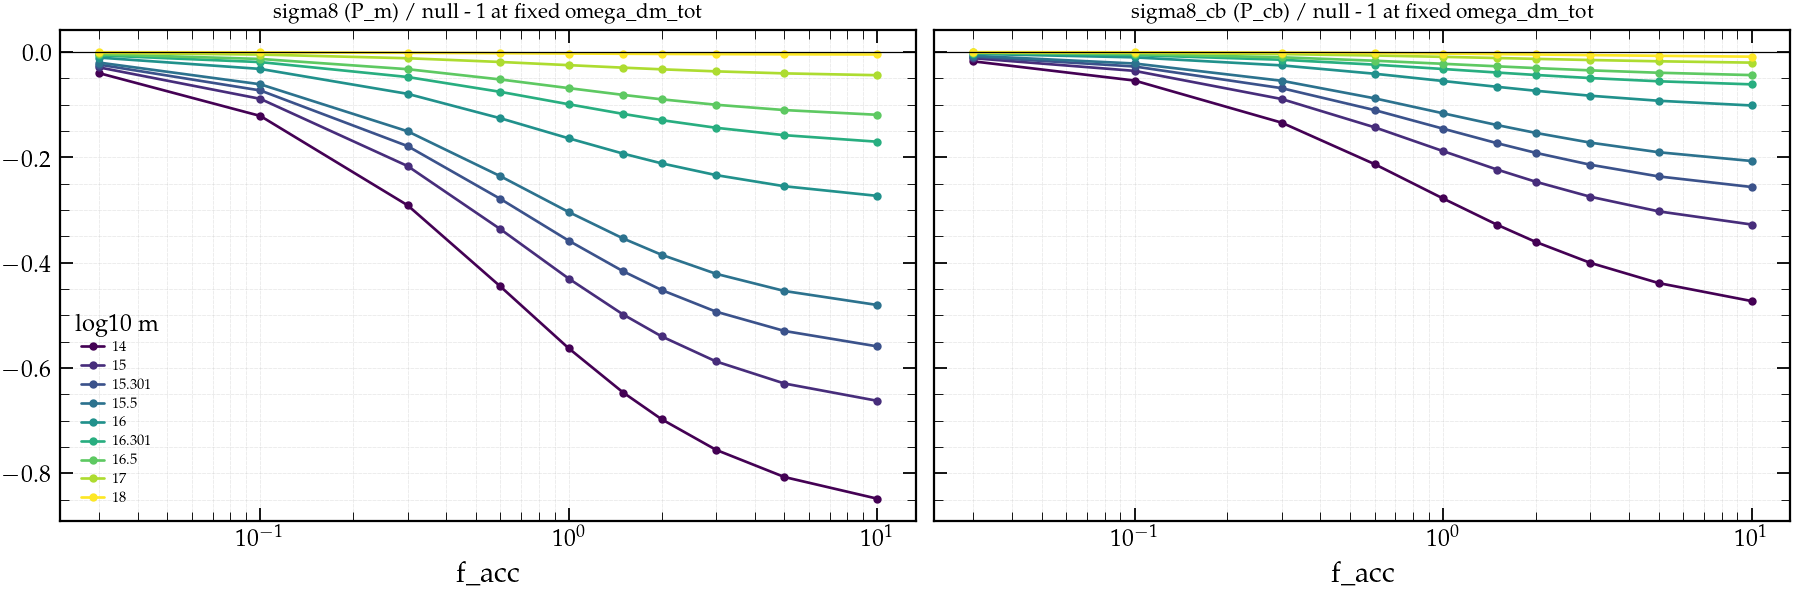

,sigma8 null,sigma8 f=0.1,sigma8_cb f=0.1,sigma8 f=1,sigma8_cb f=1,sigma8 f=10,sigma8_cb f=10
log10m,,,,,,,
14.000,0.8073,0.7094,0.7670,0.3530,0.5854,0.1226,0.4274
15.000,0.8073,0.7357,0.7819,0.4599,0.6584,0.2726,0.5453
15.301,0.8073,0.7486,0.7887,0.5181,0.6929,0.3561,0.6031
15.500,0.8073,0.7580,0.7933,0.5620,0.7166,0.4196,0.6431
16.000,0.8073,0.7816,0.8027,0.6751,0.7663,0.5869,0.7286
16.301,0.8073,0.7920,0.8062,0.7273,0.7848,0.6699,0.7611
16.500,0.8073,0.7969,0.8077,0.7521,0.7928,0.7112,0.7754
17.000,0.8073,0.8036,0.8096,0.7873,0.8035,0.7719,0.7946
18.000,0.8073,0.8069,0.8105,0.8052,0.8086,0.8037,0.8038


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, constrained_layout=True)
for i, m in enumerate(LOG10_MASSES):
    null = grid[(m, F_NULL)]
    for ax, name in zip(axes, ('sigma8', 'sigma8_cb')):
        y = [grid[(m, f)][name]/null[name] - 1 if ok(grid[(m, f)]) else np.nan for f in F_GRID]
        ax.semilogx(F_GRID, y, 'o-', ms=3, color=colour(i), label='{:g}'.format(m))
for ax, name in zip(axes, ('sigma8 (P_m)', 'sigma8_cb (P_cb)')):
    ax.axhline(0, color='k', lw=0.6)
    ax.set_xlabel('f_acc')
    ax.set_title('{} / null - 1 at fixed omega_dm_tot'.format(name), fontsize=10)
    ax.grid(alpha=0.3, which='both')
axes[0].legend(title='log10 m', fontsize=7)
plt.show()

F_TABLE = [0.1, 1.0, 10.0]
rows = []
for m in LOG10_MASSES:
    row = {'log10m': m, 'sigma8 null': grid[(m, F_NULL)]['sigma8']}
    for f in F_TABLE:
        row['sigma8 f={:g}'.format(f)] = grid[(m, f)].get('sigma8', np.nan)
        row['sigma8_cb f={:g}'.format(f)] = grid[(m, f)].get('sigma8_cb', np.nan)
    rows.append(row)
display(pd.DataFrame(rows).set_index('log10m').round(4))

## 3. Where in k

P_cb and P_m at f_acc = 1 over the null. The step moves to larger k as the mass grows and the kick shrinks.
Below the free-streaming scale the daughters do not cluster, so P_m/null → (ω_cb/ω_m)²·P_cb/null: the dotted
line is (ω_cb/ω_m)² alone, and P_m falls below it by the extra suppression of P_cb, since CDM and baryons
grow more slowly without the daughters' gravity.

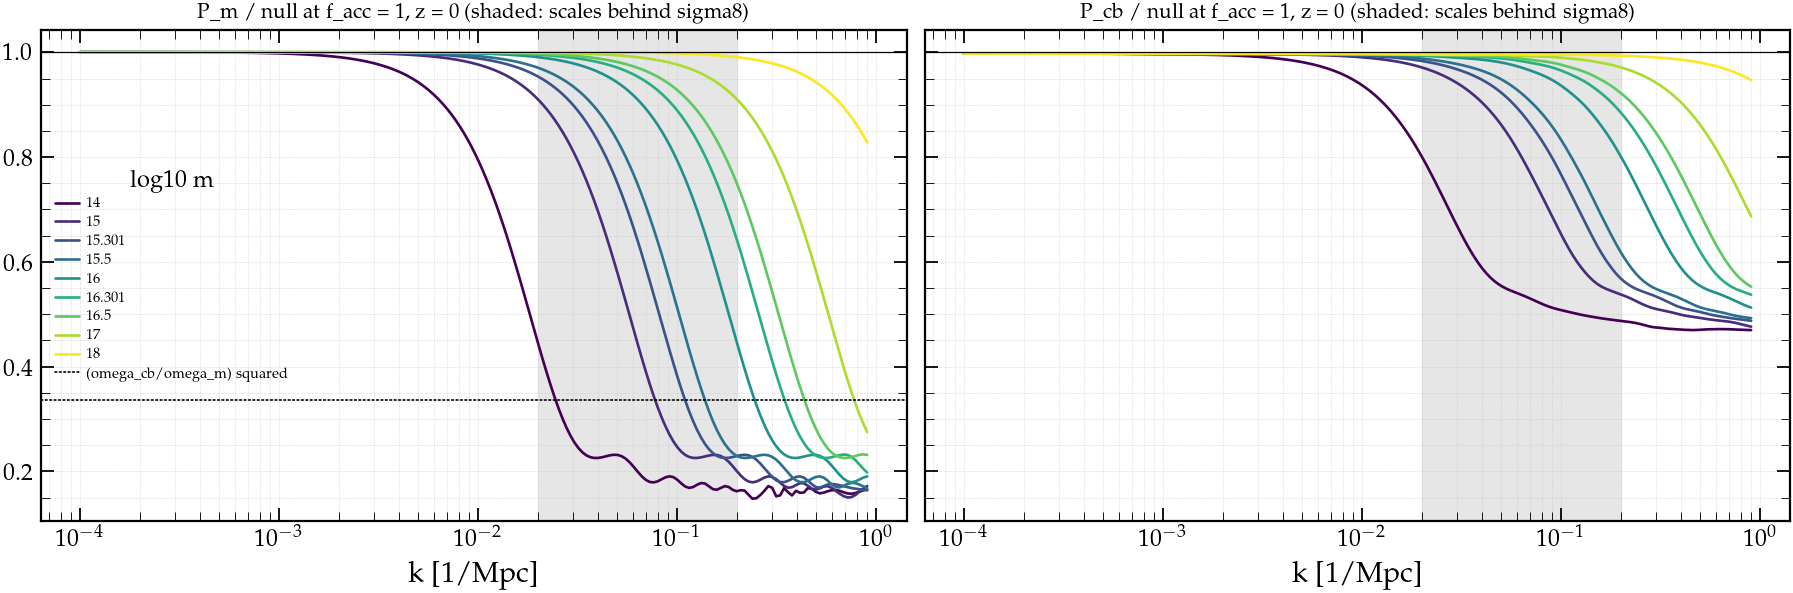

In [4]:
F_PK = 1.0
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, constrained_layout=True)
for i, m in enumerate(LOG10_MASSES):
    a, null = grid[(m, F_PK)], grid[(m, F_NULL)]
    if not ok(a):
        continue
    axes[0].semilogx(KK, a['pk_m']/null['pk_m'], color=colour(i), label='{:g}'.format(m))
    axes[1].semilogx(KK, a['pk_cb']/null['pk_cb'], color=colour(i))
for ax, name in zip(axes, ('P_m', 'P_cb')):
    ax.axhline(1, color='k', lw=0.6)
    ax.axvspan(0.02, 0.2, color='0.9', zorder=0)
    ax.set_xlabel('k [1/Mpc]')
    ax.set_title('{} / null at f_acc = {:g}, z = 0 (shaded: scales behind sigma8)'.format(name, F_PK), fontsize=10)
    ax.grid(alpha=0.3, which='both')
omega_cb = LCDM['omega_b'] + OMEGA_DM_TOT/(1 + F_PK)
axes[0].axhline((omega_cb/(LCDM['omega_b'] + OMEGA_DM_TOT))**2, color='k', ls=':', lw=0.8,
                label='(omega_cb/omega_m) squared')
axes[0].legend(title='log10 m', fontsize=7)
plt.show()

## 4. Δχ² along the ridge

Approximate Δχ² of each run against the null at the same mass, split into CMB, lensing and BAO, with all other
parameters fixed (nb33's approximation; a sensitivity scale, not a likelihood). The table gives the f_acc where
Δχ² first reaches 1 and 4. Where Δχ² stays below 1 up to f_acc = 10, the data cannot tell daughters from CDM at
that mass and the ridge is flat: any f_acc limit there comes from the prior edge.

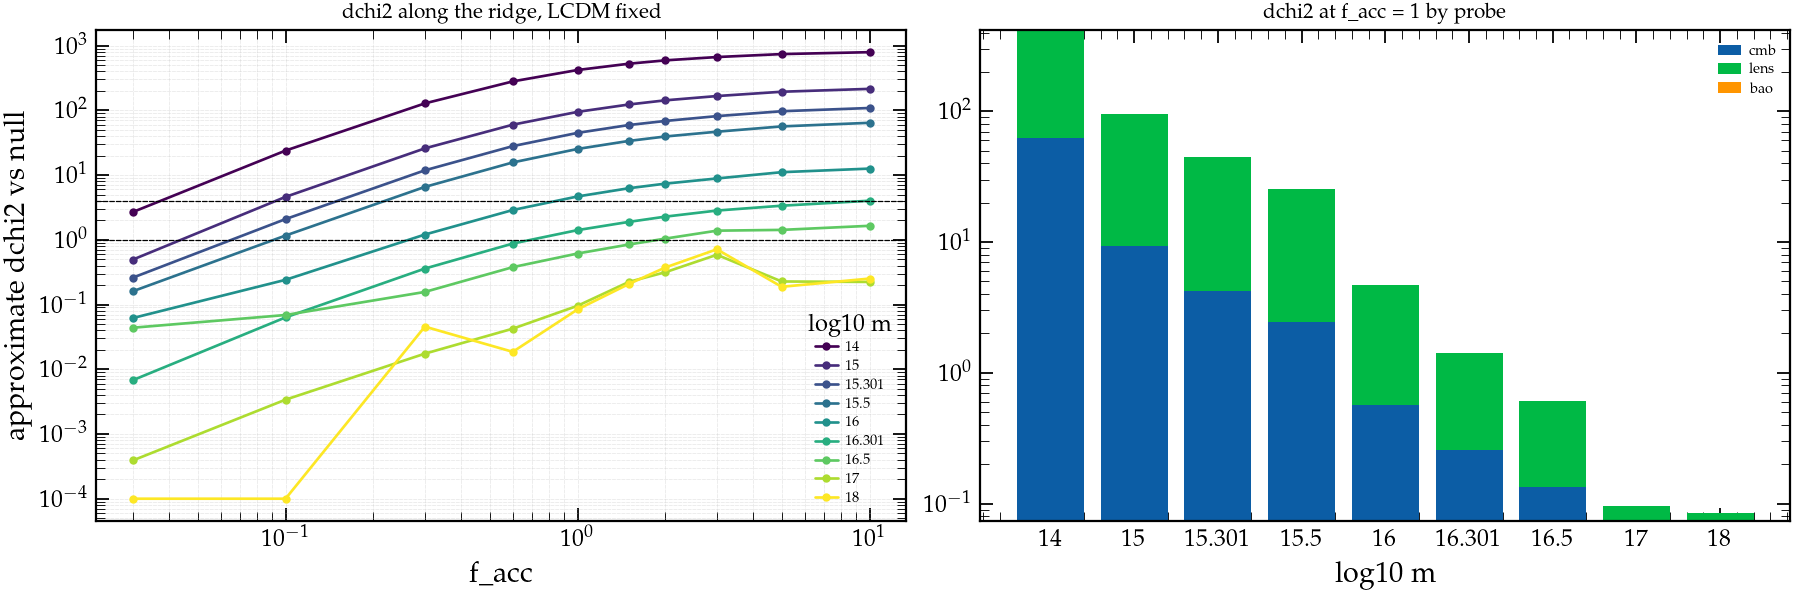

,f_acc at dchi2=1,f_acc at dchi2=4,dchi2 f=1,CMB,lens,BAO,dchi2 f=10
log10m,,,,,,,
14.000,0.030,0.032,419.309,62.733,356.576,0.0,790.526
15.000,0.035,0.084,94.577,9.254,85.323,0.0,214.379
15.301,0.049,0.124,44.812,4.250,40.562,0.0,108.545
15.500,0.082,0.178,25.291,2.438,22.853,0.0,64.112
16.000,0.238,0.826,4.668,0.568,4.100,0.0,12.574
16.301,0.677,9.903,1.410,0.257,1.153,0.0,4.009
16.500,1.879,inf,0.613,0.134,0.479,0.0,1.644
17.000,inf,inf,0.096,0.073,0.022,0.0,0.223
18.000,inf,inf,0.084,0.070,0.014,0.0,0.252


In [5]:
ELL = np.arange(2, LMAX + 1)
FSKY = 0.6
ARCMIN = np.pi/(180*60)
BEAM, NOISE_T, NOISE_P = 7.0*ARCMIN, 33.0*ARCMIN, 70.0*ARCMIN    # beam in rad, noise in uK rad
SIGMA_LENS = 0.025
SIGMA_BAO = 0.01
L_LENS = (ELL >= 8) & (ELL <= 400)


def noise_cl(sigma, t_cmb):
    """Beam-deconvolved white noise in the dimensionless units of lensed_cl."""
    return (sigma/(t_cmb*1e6))**2*np.exp(ELL*(ELL + 1)*BEAM**2/(8*np.log(2)))


def chi2_parts(a, b):
    """Approximate delta chi2 of run a against run b, per probe."""
    tt = b['tt'] + noise_cl(NOISE_T, b['T_cmb'])
    ee = b['ee'] + noise_cl(NOISE_P, b['T_cmb'])
    te = b['te']
    d = np.array([a['tt'] - b['tt'], a['ee'] - b['ee'], a['te'] - b['te']]).T
    cov = np.array([[2*tt**2, 2*te**2, 2*tt*te],
                    [2*te**2, 2*ee**2, 2*ee*te],
                    [2*tt*te, 2*ee*te, tt*ee + te**2]])/((2*ELL + 1)*FSKY)
    x = np.linalg.solve(np.moveaxis(cov, 2, 0), d[:, :, None])[:, :, 0]
    cmb = float(np.sum(d*x))
    w = (2*ELL + 1)[L_LENS]
    a_lens = np.sum(w*(a['pp']/b['pp'] - 1)[L_LENS])/np.sum(w)
    lens = float((a_lens/SIGMA_LENS)**2)
    bao = float(np.sum((a['DM_rd']/b['DM_rd'] - 1)**2 + (a['DH_rd']/b['DH_rd'] - 1)**2)/SIGMA_BAO**2)
    return {'total': cmb + lens + bao, 'cmb': cmb, 'lens': lens, 'bao': bao}


def first_crossing(f, y, level):
    """Smallest f where y reaches level, interpolated in log f; inf if never."""
    f, y = np.asarray(f), np.asarray(y)
    above = np.nonzero(y >= level)[0]
    if len(above) == 0:
        return np.inf
    i = above[0]
    if i == 0:
        return f[0]
    return float(np.exp(np.interp(level, [y[i - 1], y[i]], np.log([f[i - 1], f[i]]))))


chi2 = {k: chi2_parts(grid[k], grid[(k[0], F_NULL)]) for k in keys if k[1] != F_NULL and ok(grid[k])}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
rows = []
for i, m in enumerate(LOG10_MASSES):
    fs = [f for f in F_GRID if (m, f) in chi2]
    tot = [chi2[(m, f)]['total'] for f in fs]
    axes[0].loglog(fs, np.maximum(tot, 1e-4), 'o-', ms=3, color=colour(i), label='{:g}'.format(m))
    c1 = chi2.get((m, 1.0), {})
    rows.append({'log10m': m, 'f_acc at dchi2=1': first_crossing(fs, tot, 1),
                 'f_acc at dchi2=4': first_crossing(fs, tot, 4),
                 'dchi2 f=1': c1.get('total'), 'CMB': c1.get('cmb'), 'lens': c1.get('lens'), 'BAO': c1.get('bao'),
                 'dchi2 f=10': chi2.get((m, 10.0), {}).get('total')})
for level in (1, 4):
    axes[0].axhline(level, color='k', ls='--', lw=0.6)
axes[0].set_xlabel('f_acc')
axes[0].set_ylabel('approximate dchi2 vs null')
axes[0].set_title('dchi2 along the ridge, LCDM fixed', fontsize=10)
axes[0].legend(title='log10 m', fontsize=7)
axes[0].grid(alpha=0.3, which='both')

parts = ['cmb', 'lens', 'bao']
x = np.arange(len(LOG10_MASSES))
bottom = np.zeros(len(LOG10_MASSES))
for part in parts:
    v = np.array([chi2.get((m, 1.0), {}).get(part, np.nan) for m in LOG10_MASSES])
    axes[1].bar(x, v, bottom=bottom, label=part)
    bottom += np.nan_to_num(v)
axes[1].set_yscale('log')
axes[1].set_xticks(x, ['{:g}'.format(m) for m in LOG10_MASSES])
axes[1].set_xlabel('log10 m')
axes[1].set_title('dchi2 at f_acc = 1 by probe', fontsize=10)
axes[1].legend(fontsize=7)
plt.show()
display(pd.DataFrame(rows).set_index('log10m').round(3))

## 5. Emulator σ8 against CLASS at chain samples

For each fixed-mass chain from 10¹⁵ GeV up, ten samples at evenly spaced f_acc quantiles of the posterior are run
through CLASS with the chain's own parameters, and CLASS σ8 is compared with the `sigma8` the emulator wrote into
the chain. σ8 is one emulated output, so agreement here does not prove the C_ℓ are right, but a disagreement
localises where the emulator is off.

If the offset is the same at all f_acc, including f_acc ≈ 0, the emulator was more likely trained with settings
different from `SETTINGS` than wrong; the emulator names printed below say which model each chain used.

15      'accDM_k12.1at0.133_m15_strat5'
15.301  'accDM_k12.1at0.133_m15p301_strat5'


16      'accDM_k12.1at0.133_m16_strat5'
16.301  'accDM_k12.1at0.133_m16p301_strat5'


17      'accDM_k12.1at0.133_m17_strat5_4'
18      'accDM_k12.1at0.133_m18_strat5'
failed CLASS runs: 0


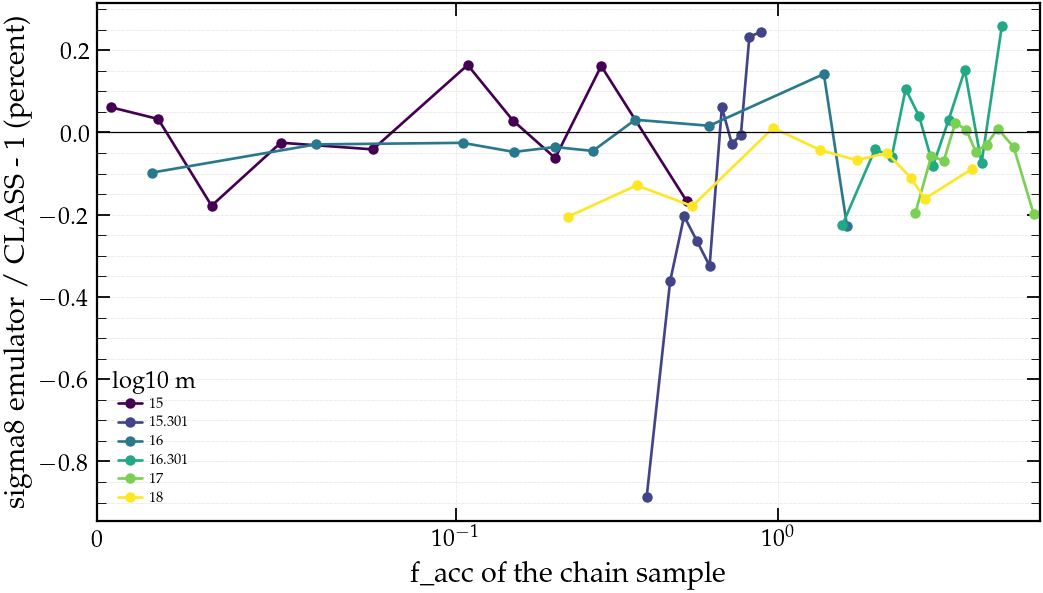

n  median [%]  max |.| [%]
log10m region                                   
15.000 f_acc < 0.5    9        0.03         0.18
       f_acc >= 0.5   1       -0.17         0.17
15.301 f_acc < 0.5    2       -0.62         0.89
       f_acc >= 0.5   8       -0.02         0.32
16.000 f_acc < 0.5    7       -0.04         0.10
       f_acc >= 0.5   3        0.02         0.23
16.301 f_acc >= 0.5  10       -0.01         0.26
17.000 f_acc >= 0.5  10       -0.04         0.20
18.000 f_acc < 0.5    2       -0.17         0.20
       f_acc >= 0.5   8       -0.08         0.18

In [6]:
N_PER = 10
QUANTILES = np.linspace(0.03, 0.97, N_PER)
CHAIN_KEYS = ('omega_b', 'omega_cdm', 'H0', 'ln10^{10}A_s', 'n_s', 'tau_reio', 'f_acc')

picks = []
for d in chain_dirs(min_log10m=15):
    m, s = float(d.name), load_chain(d)
    model = next((line.split('=')[1].strip() for line in open(d/'log.param')
                  if line.startswith("data.cosmo_arguments['connect_model']")), '?')
    print('{:<7g} {}'.format(m, model))
    order = np.argsort(s['f_acc'])
    cdf = np.cumsum(s['weight'][order])
    for q in QUANTILES:
        i = order[min(np.searchsorted(cdf, q*cdf[-1]), len(order) - 1)]
        picks.append({'log10m': m, 'sigma8_emu': s['sigma8'][i], **{k: s[k][i] for k in CHAIN_KEYS}})

check = run_cached([{**SETTINGS, **{k: p[k] for k in CHAIN_KEYS}, 'm_acc_in_GeV': 10**p['log10m']}
                    for p in picks])
emu = pd.DataFrame(picks)
emu['sigma8_class'] = [c.get('sigma8', np.nan) for c in check]
emu['rel diff'] = emu['sigma8_emu']/emu['sigma8_class'] - 1
print('failed CLASS runs:', int(emu['sigma8_class'].isna().sum()))

masses = sorted(emu['log10m'].unique())
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
for i, m in enumerate(masses):
    e = emu[emu['log10m'] == m]
    ax.plot(e['f_acc'], 100*e['rel diff'], 'o-', ms=4, color=plt.cm.viridis(i/max(len(masses) - 1, 1)),
            label='{:g}'.format(m))
ax.axhline(0, color='k', lw=0.6)
ax.set_xscale('symlog', linthresh=0.1)
ax.set_xlim(left=0)
ax.set_xlabel('f_acc of the chain sample')
ax.set_ylabel('sigma8 emulator / CLASS - 1 (percent)')
ax.legend(title='log10 m', fontsize=7)
ax.grid(alpha=0.3, which='both')
plt.show()

summary = emu.assign(region=np.where(emu['f_acc'] < 0.5, 'f_acc < 0.5', 'f_acc >= 0.5'))
display(summary.groupby(['log10m', 'region'])['rel diff']
        .agg(n='size', median='median', max_abs=lambda v: np.max(np.abs(v))).mul([1, 100, 100]).round(2)
        .rename(columns={'median': 'median [%]', 'max_abs': 'max |.| [%]'}))

## Reading the result

Numbers below are from the run of 2026-10-01 and the chains in `connect/new` at that date.

- **Section 2:** at f_acc = 1, σ8 drops by 56% at 10¹⁴ GeV, 16% at 10¹⁶, 2.5% at 10¹⁷ and 0.3% at 10¹⁸. σ8_cb
  drops much less (27%, 5%, 0.5%, 0%): most of the σ8 loss is daughters that do not cluster, not slower growth
  of CDM. The ridge is not flat below about 10¹⁷ GeV.
- **Section 4:** BAO contributes nothing at any mass, because fixing ω_dm,tot fixes the expansion history; the
  signal is 80–90% CMB lensing. At fixed ΛCDM, Δχ² = 4 is reached at f_acc ≈ 0.03 (10¹⁴), 0.08 (10¹⁵), 0.8 (10¹⁶)
  and 10 (10^16.3); from 10^16.5 up it never is. Above 10^16.5 the curves are non-monotonic at the 0.1–0.7
  level, which is the numerical noise floor of these settings, not physics: there the ridge is flat and the
  f_acc posterior is set by the prior (nb34, section 4).
- **Section 5:** the emulator's σ8 matches CLASS to 0.3% at every sampled point except one (−0.9% at 10^15.3,
  f_acc ≈ 0.4), so the σ8 output is fine wherever the chains go. The samples only cover where each chain is, so
  this says nothing about the emulator near f_acc = 0 for chains that never go there.

Against the chains (nb34, section 2), CLASS says three of them are in the wrong place:

- **10^15.3:** the chain has no weight below f_acc ≈ 0.35, while CLASS puts f_acc ≈ 0.5 at Δχ² ≈ 25 above
  f_acc = 0 with ΛCDM fixed; its best fit is 7 worse in −log L than the ΛCDM-like masses.
- **10^16.3 and 10¹⁷:** the chains never visit f_acc < 1 and < 2.3, although CLASS says the ridge is flat there
  or rises with f_acc. With a flat ridge the previous prior favours small f_acc (nb34, section 4), so a chain
  should spend most of its time there.
- **10¹⁶:** CLASS's Δχ² rises monotonically along the ridge, so the second peak at f_acc ≈ 1.5 has no
  counterpart at fixed ΛCDM. Compensation by the other parameters would have to undo Δχ² ≈ 6 there.

Since σ8 is right, the likely culprit is the emulated C_ℓ near f_acc = 0, the region the previous parametrization
covers worst (nb34, section 3). The decisive test is the χ² validation in
`cluster_scripts/emulator_chi2_validation.py` at samples near f_acc = 0 and in the chains' preferred regions.